In [1]:
# Importing libraries
import os
import requests
import io
import zipfile
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc, f1_score
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [2]:
sns.set(style="whitegrid")

# Download dataset (Lending Club granting-model dataset)
DATA_DIR = "./data"
os.makedirs(DATA_DIR, exist_ok=True)
csv_path = os.path.join(DATA_DIR, "LC_loans_granting_model_dataset.csv")
zenodo_url = "https://zenodo.org/records/11295916/files/LC_loans_granting_model_dataset.csv?download=1"

if not os.path.exists(csv_path):
    print("Downloading Lending Club CSV from Zenodo (this may take a moment)...")
    r = requests.get(zenodo_url, stream=True)
    if r.status_code == 200:
        with open(csv_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=1024*1024):
                if chunk:
                    f.write(chunk)
        print("Downloaded to:", csv_path)
    else:
        raise RuntimeError(f"Failed to download dataset from Zenodo (status {r.status_code}). "
                           "Open the Zenodo page and download manually: https://zenodo.org/records/11295916")


In [3]:
import pandas as pd
print("Loading CSV...")
df = pd.read_csv(csv_path)
print("Rows, cols:", df.shape)
display(df.head(3))

Loading CSV...


C:\Users\LAYBA ALI\AppData\Local\Temp\ipykernel_2124\2264121521.py:3: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


Rows, cols: (1347681, 15)


,id,issue_d,revenue,dti_n,loan_amnt,fico_n,experience_c,emp_length,purpose,home_ownership_n,addr_state,zip_code,Default,title,desc
0,68407277,Dec-2015,55000.0,5.91,3600,677.0,1,10+ years,debt_consolidation,MORTGAGE,PA,190xx,0,Debt consolidation,NaN
1,68355089,Dec-2015,65000.0,16.06,24700,717.0,1,10+ years,small_business,MORTGAGE,SD,577xx,0,Business,NaN
2,68341763,Dec-2015,71000.0,13.85,20000,697.0,1,10+ years,home_improvement,MORTGAGE,IL,605xx,0,NaN,NaN


In [4]:
# Define the mapping for renaming
rename_map = {
    'revenue': 'annual_income',
    'fico_n': 'credit_score'
}

# Apply the renaming to the DataFrame
df.rename(columns=rename_map, inplace=True)

print("Columns renamed successfully.")
print("New column names: annual_income and credit_score")

Columns renamed successfully.
New column names: annual_income and credit_score


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1347681 entries, 0 to 1347680
Data columns (total 15 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   id                1347681 non-null  int64  
 1   issue_d           1347681 non-null  object 
 2   annual_income     1347681 non-null  float64
 3   dti_n             1347681 non-null  float64
 4   loan_amnt         1347681 non-null  int64  
 5   credit_score      1347681 non-null  float64
 6   experience_c      1347681 non-null  int64  
 7   emp_length        1347681 non-null  object 
 8   purpose           1347681 non-null  object 
 9   home_ownership_n  1347681 non-null  object 
 10  addr_state        1347681 non-null  object 
 11  zip_code          1347680 non-null  object 
 12  Default           1347681 non-null  int64  
 13  title             1331024 non-null  object 
 14  desc              119099 non-null   object 
dtypes: float64(3), int64(4), object(8)
memory usage: 

In [6]:
# Calculate the number of missing values per column
missing_count = df.isnull().sum()

# Calculate the percentage of missing values
total_rows = len(df)
missing_percentage = (missing_count / total_rows) * 100

# Create a DataFrame for easy viewing and sorting
missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Percent Missing': missing_percentage
})

# Filter out columns with 0 missing values and sort by percentage
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(
    by='Percent Missing', 
    ascending=False
)

print(missing_df)

          Missing Count  Percent Missing
desc            1228582        91.162671
title             16657         1.235975
zip_code              1         0.000074


In [7]:
# List the columns to drop
cols_to_drop = ['title', 'desc']

# Drop the columns using errors='ignore' in case one of them was already dropped
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print("Columns dropped successfully. DataFrame updated.")

Columns dropped successfully. DataFrame updated.


In [8]:
# 6 Impute Remaining Missing Values 
# Impute numeric columns with the median (robust to remaining outliers)
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        # FIXED: Use direct assignment instead of inplace=True
        df[col] = df[col].fillna(median_val)

# Impute categorical/object columns with the mode (most frequent value)
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        # FIXED: Use direct assignment instead of inplace=True
        df[col] = df[col].fillna(mode_val)


In [9]:
#checking if any column have null values
df.columns[df.isnull().any()]

Index([], dtype='object')

In [10]:
df.head()

,id,issue_d,annual_income,dti_n,loan_amnt,credit_score,experience_c,emp_length,purpose,home_ownership_n,addr_state,zip_code,Default
0,68407277,Dec-2015,55000.0,5.91,3600,677.0,1,10+ years,debt_consolidation,MORTGAGE,PA,190xx,0
1,68355089,Dec-2015,65000.0,16.06,24700,717.0,1,10+ years,small_business,MORTGAGE,SD,577xx,0
2,68341763,Dec-2015,71000.0,13.85,20000,697.0,1,10+ years,home_improvement,MORTGAGE,IL,605xx,0
3,68476807,Dec-2015,104433.0,25.37,10400,697.0,1,3 years,major_purchase,MORTGAGE,PA,174xx,0
4,68426831,Dec-2015,34000.0,10.20,11950,692.0,1,4 years,debt_consolidation,RENT,GA,300xx,0


In [11]:
# CLass Dsitribution
TARGET_COL = 'Default'
RANDOM_STATE = 42
print(f"\nClass Distribution ({TARGET_COL})")
target_counts = df[TARGET_COL].value_counts(normalize=True)
print(target_counts)


Class Distribution (Default)
Default
0    0.800213
1    0.199787
Name: proportion, dtype: float64


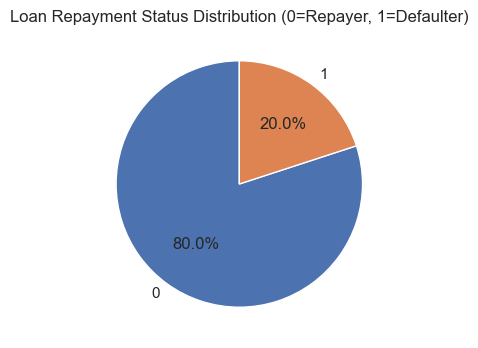

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Pie Chart for Imbalance
plt.figure(figsize=(6, 4))
df['Default'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Loan Repayment Status Distribution (0=Repayer, 1=Defaulter)')
plt.ylabel('')
plt.show()

Plotting key numerical features (DTI and Loan Amount)...


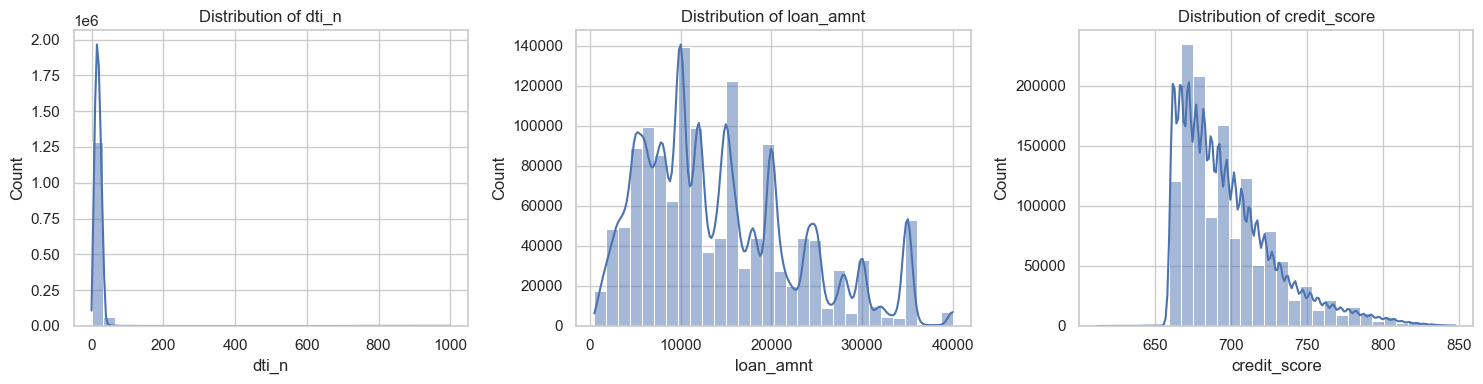

In [13]:
# Create temporary ratio features if they don't exist yet, as they are crucial
if 'DTI_Ratio' not in df.columns and 'dti_n' in df.columns and 'loan_amnt' in df.columns:
    print("Plotting key numerical features (DTI and Loan Amount)...")

    numerical_cols_to_plot = ['dti_n', 'loan_amnt', 'credit_score']

    plt.figure(figsize=(15, 4))
    for i, col in enumerate(numerical_cols_to_plot):
        if col in df.columns:
            plt.subplot(1, 3, i + 1)
            sns.histplot(df[col], kde=True, bins=30)
            plt.title(f'Distribution of {col}', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("Could not plot numerical features.")

Since the distribution is complex and not easily normalized, tree-based models like CatBoost and XGBoost are ideal. They can naturally split the data around these cluster points. We also utilized this feature to create the highly predictive loan_income_ratio.


Generating comparison plots for key categorical risk factors...


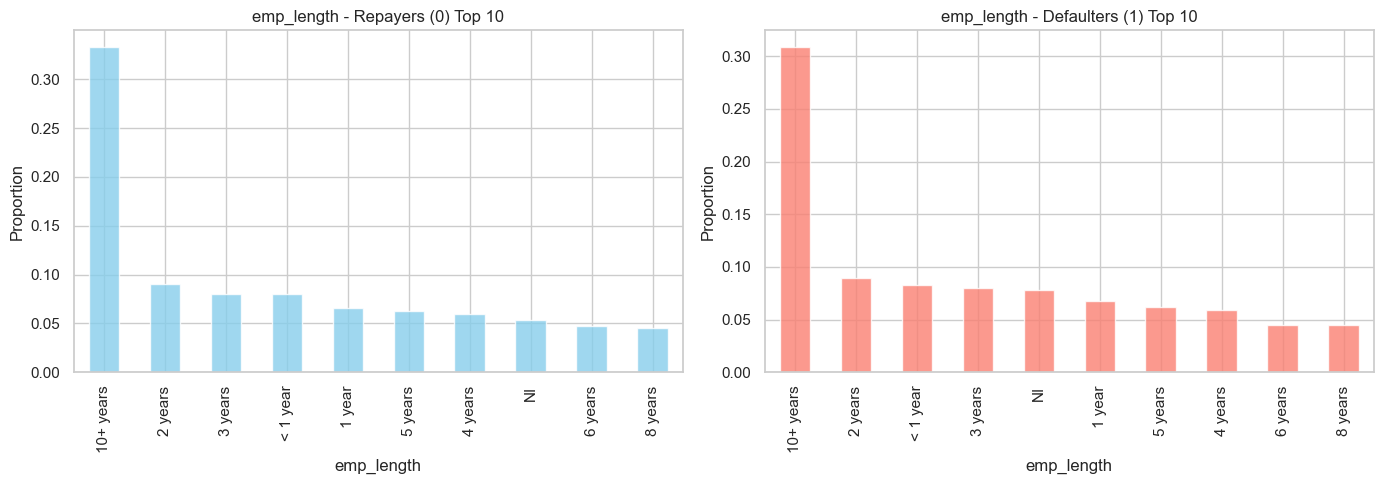

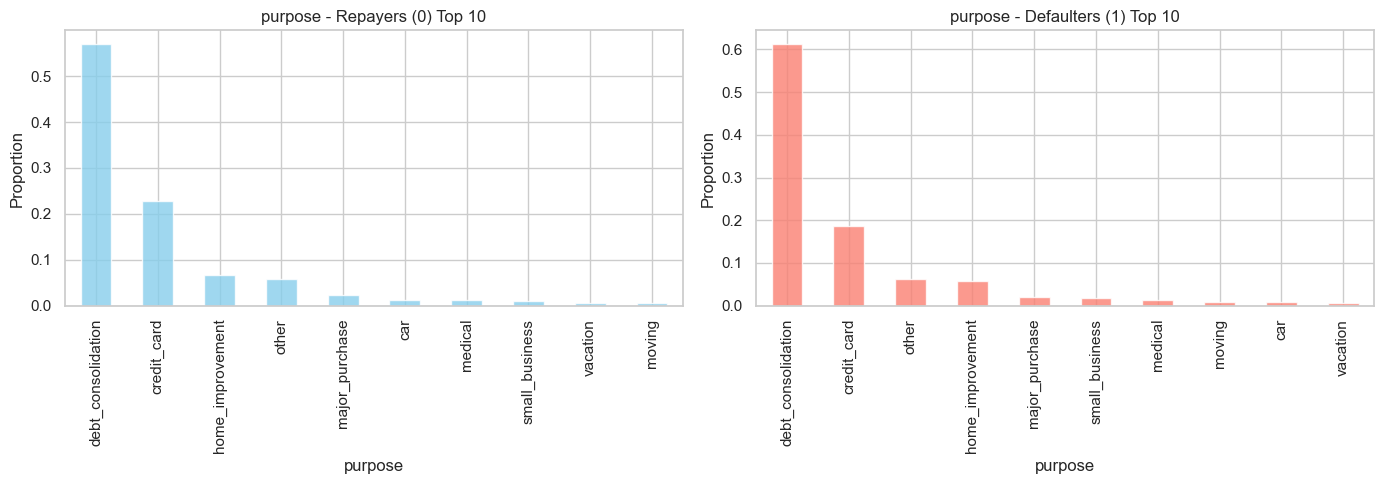

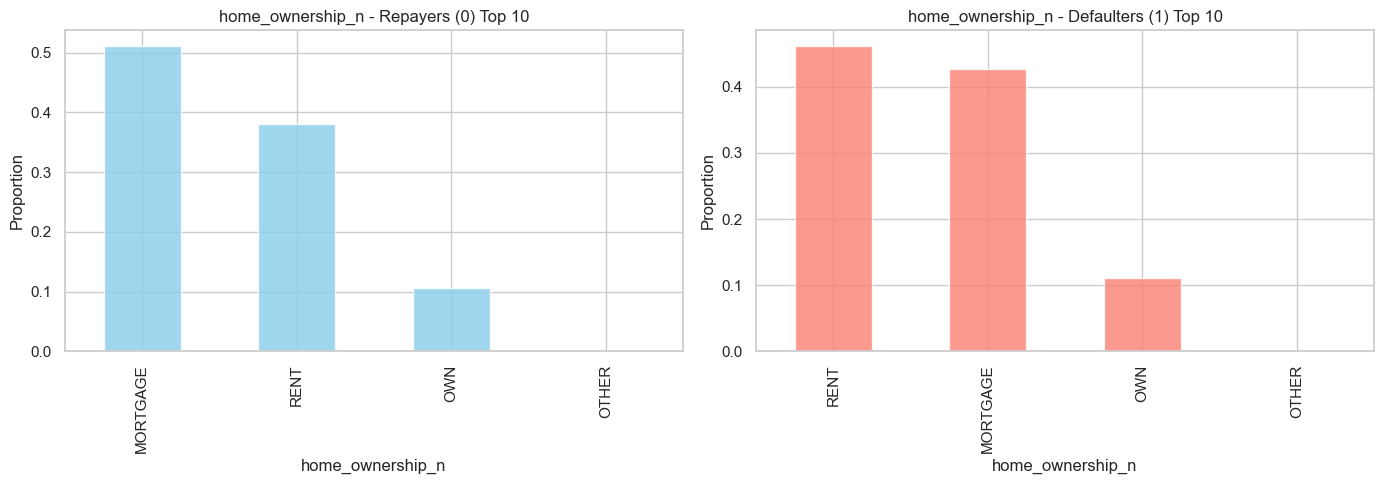

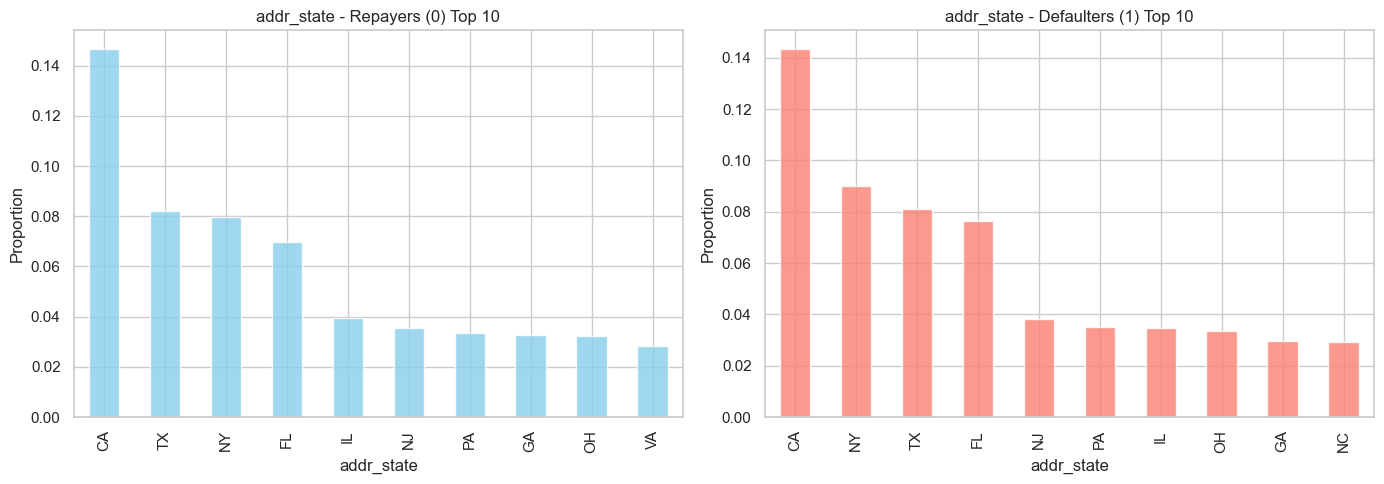

In [14]:
# Define key categorical features present in the sample
categorical_cols_for_comparison = [
    'emp_length',        # Employment Length (e.g., '10+ years')
    'purpose',           # Loan Purpose
    'home_ownership_n',  # Home Ownership
    'addr_state'         # State
]

# Separate the data based on the correct target column: 'Default'
target_0_data = df[df['Default'] == 0]
target_1_data = df[df['Default'] == 1]

print("\nGenerating comparison plots for key categorical risk factors...")

for col in categorical_cols_for_comparison:
    if col in df.columns:
        plt.figure(figsize=(14, 5))

        # Plot for Repayers (Target = 0)
        plt.subplot(1, 2, 1)
        df_counts_0 = target_0_data[col].value_counts(normalize=True).sort_values(ascending=False).head(10)
        df_counts_0.plot(kind='bar', color='skyblue', alpha=0.8)
        plt.title(f'{col} - Repayers (0) Top 10', fontsize=12)
        plt.ylabel('Proportion')

        # Plot for Defaulters (Target = 1)
        plt.subplot(1, 2, 2)
        df_counts_1 = target_1_data[col].value_counts(normalize=True).sort_values(ascending=False).head(10)
        df_counts_1.plot(kind='bar', color='salmon', alpha=0.8)
        plt.title(f'{col} - Defaulters (1) Top 10', fontsize=12)
        plt.ylabel('Proportion')

        plt.tight_layout()
        plt.show()

In [17]:
df_working = df.copy()
df_working.head()

,id,issue_d,annual_income,dti_n,loan_amnt,credit_score,experience_c,emp_length,purpose,home_ownership_n,addr_state,zip_code,Default
0,68407277,Dec-2015,55000.0,5.91,3600,677.0,1,10+ years,debt_consolidation,MORTGAGE,PA,190xx,0
1,68355089,Dec-2015,65000.0,16.06,24700,717.0,1,10+ years,small_business,MORTGAGE,SD,577xx,0
2,68341763,Dec-2015,71000.0,13.85,20000,697.0,1,10+ years,home_improvement,MORTGAGE,IL,605xx,0
3,68476807,Dec-2015,104433.0,25.37,10400,697.0,1,3 years,major_purchase,MORTGAGE,PA,174xx,0
4,68426831,Dec-2015,34000.0,10.20,11950,692.0,1,4 years,debt_consolidation,RENT,GA,300xx,0


In [18]:
df_working.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1347681 entries, 0 to 1347680
Data columns (total 13 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   id                1347681 non-null  int64  
 1   issue_d           1347681 non-null  object 
 2   annual_income     1347681 non-null  float64
 3   dti_n             1347681 non-null  float64
 4   loan_amnt         1347681 non-null  int64  
 5   credit_score      1347681 non-null  float64
 6   experience_c      1347681 non-null  int64  
 7   emp_length        1347681 non-null  object 
 8   purpose           1347681 non-null  object 
 9   home_ownership_n  1347681 non-null  object 
 10  addr_state        1347681 non-null  object 
 11  zip_code          1347681 non-null  object 
 12  Default           1347681 non-null  int64  
dtypes: float64(3), int64(4), object(6)
memory usage: 133.7+ MB


In [19]:
# 3. Date Feature Engineering
date_cols = ['issue_d']
for col in date_cols:
    if col in df_working.columns:
        # Standardize date parsing format (Lending Club dates are often %b-%Y)
        df_working[col] = pd.to_datetime(df_working[col], errors='coerce', format='%b-%Y')
        print(f"Standardized date format for column '{col}'.")

# Find the reference date for age calculation (latest issue_d)
if 'issue_d' in df_working.columns and not df_working['issue_d'].isnull().all():
    latest_date = df_working['issue_d'].max()
    print(f"Reference date (latest issue_d) set to: {latest_date.strftime('%b-%Y')}")
else:
    latest_date = pd.to_datetime('Dec-2020', format='%b-%Y')
    print("Reference date defaulted to Dec-2020.")

Standardized date format for column 'issue_d'.
Reference date (latest issue_d) set to: Dec-2018


In [20]:
# --- 4. Target Leakage Check (Crucial for Internship Project Integrity) ---
# NOTE: We remove payment/recovery columns that are only known AFTER the loan result.
leakage_cols = [
    'recoveries', 'total_rec_late_fee', 'collection_recovery_fee',
    'last_pymnt_d', 'last_pymnt_amnt', 'out_prncp', 'out_prncp_inv'
]
df_working = df_working.drop(columns=[col for col in leakage_cols if col in df_working.columns], errors='ignore')

In [21]:
# Outlier Treatment (DTI Capping) and Final Imputation 
# 6.1 Outlier Treatment: Capping DTI_N (Based on Box Plot Analysis)
dti_col = 'dti_n'
if dti_col in df_working.columns:
    # Cap DTI at 100 as extreme values are financially meaningless or errors.
    df_working[dti_col] = np.where(df_working[dti_col] > 100, 100, df_working[dti_col])
    print(f"Capped extreme outliers in '{dti_col}' at 100.")

Capped extreme outliers in 'dti_n' at 100.


In [22]:
#  Drop Non-Predictive/Processed Columns 
date_cols_to_drop = [c for c in date_cols if c in df_working.columns]
df_working = df_working.drop(columns=date_cols_to_drop, errors='ignore')
# experience_c was near-constant; desc/title are removed as high-cardinality text fields
df_working = df_working.drop(columns=['id', 'desc', 'title', 'experience_c'], errors='ignore')

In [23]:
# Advanced Feature Engineering (Ratios and Bins) 

Credit_Score = 'credit_score'
LOAN_AMT_COL = 'loan_amnt'
REVENUE_COL = 'revenue'

# Loan-to-Income Ratio and Log Revenue
if LOAN_AMT_COL in df_working.columns and REVENUE_COL in df_working.columns:
    df_working["loan_income_ratio"] = df_working[LOAN_AMT_COL] / (df_working[REVENUE_COL] + 1e-9)
    df_working["log_revenue"] = np.log1p(df_working[REVENUE_COL])
    print("Created 'loan_income_ratio' and 'log_revenue'.")

In [24]:
# FICO Score Risk Tiers (Binning) - Highly Predictive Categorical Feature
if Credit_Score in df_working.columns:
    bins = [0, 620, 680, 740, 800, 1000]
    labels = ['Credit_Score_Very_Poor', 'Credit_Score_Fair', 'Credit_Score_Good', 'Credit_Score_Very_Good', 'Credit_Score_Excellent']

    df_working['fico_risk_tier'] = pd.cut(
        df_working[Credit_Score],
        bins=bins,
        labels=labels,
        right=False,
        include_lowest=True
    ).astype('object')
    print("Created 'fico_risk_tier'.")

Created 'fico_risk_tier'.


In [25]:
# Final Categorical Cleaning (Rare Category Collapse)
for c in df_working.select_dtypes(include=["category","object"]).columns:
    if c == TARGET_COL: continue

    df_working[c] = df_working[c].astype("category")
    topk = df_working[c].value_counts().nlargest(25).index

    if "OTHER" not in df_working[c].cat.categories:
        df_working[c] = df_working[c].cat.add_categories(["OTHER"])

    df_working[c] = df_working[c].where(df_working[c].isin(topk), other="OTHER")
    df_working[c] = df_working[c].cat.remove_unused_categories()

print(f"\nTotal clean features remaining in 'df_working': {df_working.shape[1]}")


Total clean features remaining in 'df_working': 11


In [26]:
# Data Split and Preparation 
X = df_working.drop(columns=[TARGET_COL])
y = df_working[TARGET_COL].astype(int)

categorical_cols = X.select_dtypes(include=["category", "object"]).columns.tolist()

# Stratify split ensures target class ratio is maintained
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 1078144, Test size: 269537


In [36]:
df_working.head()

,annual_income,dti_n,loan_amnt,credit_score,emp_length,purpose,home_ownership_n,addr_state,zip_code,Default,fico_risk_tier
0,55000.0,5.91,3600,677.0,10+ years,debt_consolidation,MORTGAGE,PA,OTHER,0,Credit_Score_Fair
1,65000.0,16.06,24700,717.0,10+ years,small_business,MORTGAGE,OTHER,OTHER,0,Credit_Score_Good
2,71000.0,13.85,20000,697.0,10+ years,home_improvement,MORTGAGE,IL,OTHER,0,Credit_Score_Good
3,104433.0,25.37,10400,697.0,3 years,major_purchase,MORTGAGE,PA,OTHER,0,Credit_Score_Good
4,34000.0,10.20,11950,692.0,4 years,debt_consolidation,RENT,GA,300xx,0,Credit_Score_Good


In [27]:
# Baseline Model: XGBoost with scale_pos_weight 
Xn_train = X_train.copy()
Xn_test = X_test.copy()
for c in categorical_cols:
    # Factorize train set
    Xn_train[c], unique_cats = pd.factorize(X_train[c])
    mapping = dict(zip(X_train[c].unique(), Xn_train[c].unique()))
    # Map test set, filling unseen categories (-1)
    Xn_test[c] = X_test[c].astype('object').map(mapping).fillna(-1).astype(int)

# Calculate scale_pos_weight for imbalance
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"\n[XGBoost] scale_pos_weight: {scale_pos_weight:.2f}")

xgb = XGBClassifier(
    n_estimators=600,
    learning_rate=0.04,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    random_state=RANDOM_STATE
)
print("Training XGBoost (Numeric Features)...")
xgb.fit(Xn_train, y_train)
xgb_proba = xgb.predict_proba(Xn_test)[:, 1]

# F1 Threshold Tuning
best_f1_xgb = 0; best_t_xgb = 0.5
for t in np.arange(0.1, 0.9, 0.01):
    preds = (xgb_proba >= t).astype(int)
    f1 = f1_score(y_test, preds)
    if f1 > best_f1_xgb:
        best_f1_xgb = f1; best_t_xgb = t

print(f"XGBoost Best Threshold: {best_t_xgb:.3f}, Best F1: {best_f1_xgb:.3f}")
print(classification_report(y_test, (xgb_proba >= best_t_xgb).astype(int)))



[XGBoost] scale_pos_weight: 4.01
Training XGBoost (Numeric Features)...


C:\Users\LAYBA ALI\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:199: UserWarning: [20:31:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Best Threshold: 0.510, Best F1: 0.397
              precision    recall  f1-score   support

           0       0.87      0.63      0.73    215687
           1       0.29      0.62      0.40     53850

    accuracy                           0.63    269537
   macro avg       0.58      0.62      0.56    269537
weighted avg       0.75      0.63      0.66    269537



In [28]:
# CatBoost Model (Superior Handling of Categorical Features) 
cat_features_idx = [X_train.columns.get_loc(c) for c in categorical_cols]
print(f"\n[CatBoost] Categorical feature indices: {cat_features_idx}")

cat = CatBoostClassifier(
    iterations=500,
    learning_rate=0.04,
    depth=6,
    loss_function="Logloss",
    random_state=RANDOM_STATE,
    class_weights=[1.0, scale_pos_weight],
    verbose=100
)
print("Training CatBoost (Raw Categorical Features)...")

cat.fit(
    X_train, y_train,
    cat_features=cat_features_idx,
    eval_set=(X_test, y_test)
)
cat_proba = cat.predict_proba(X_test)[:, 1]

# F1 Threshold Tuning
best_f1_cat = 0; best_t_cat = 0.5
for t in np.arange(0.1, 0.9, 0.01):
    preds = (cat_proba >= t).astype(int)
    f1 = f1_score(y_test, preds)
    if f1 > best_f1_cat:
        best_f1_cat = f1; best_t_cat = t

print(f"CatBoost Best Threshold: {best_t_cat:.3f}, Best F1: {best_f1_cat:.3f}")
print(classification_report(y_test, (cat_proba >= best_t_cat).astype(int)))



[CatBoost] Categorical feature indices: [4, 5, 6, 7, 8, 9]
Training CatBoost (Raw Categorical Features)...
0:	learn: 0.6907730	test: 0.6907699	best: 0.6907699 (0)	total: 1.69s	remaining: 14m 4s
100:	learn: 0.6498612	test: 0.6501276	best: 0.6501276 (100)	total: 2m 4s	remaining: 8m 13s
200:	learn: 0.6471203	test: 0.6476402	best: 0.6476402 (200)	total: 4m 3s	remaining: 6m 2s
300:	learn: 0.6462109	test: 0.6469589	best: 0.6469589 (300)	total: 6m 3s	remaining: 4m
400:	learn: 0.6453958	test: 0.6464631	best: 0.6464631 (400)	total: 8m 4s	remaining: 1m 59s
499:	learn: 0.6446566	test: 0.6461146	best: 0.6461146 (499)	total: 10m 5s	remaining: 0us

bestTest = 0.6461145868
bestIteration = 499

CatBoost Best Threshold: 0.500, Best F1: 0.396
              precision    recall  f1-score   support

           0       0.87      0.60      0.71    215687
           1       0.29      0.64      0.40     53850

    accuracy                           0.61    269537
   macro avg       0.58      0.62      0.55   

AUC-ROC Score - XGBoost: 0.6702
AUC-ROC Score - CatBoost: 0.6697


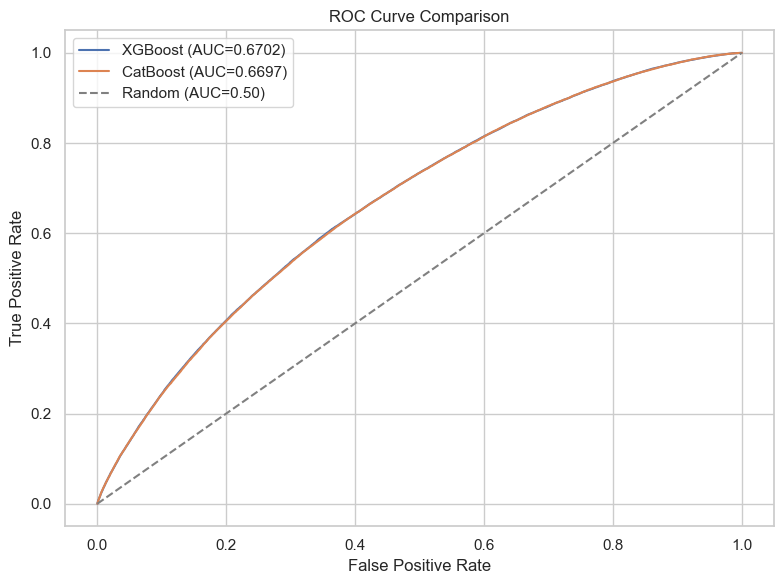

In [32]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
# Final Evaluation (AUC-ROC and PR Curve Visuals) 

# Calculate AUC-ROC for both models
auc_xgb = roc_auc_score(y_test, xgb_proba)
auc_cat = roc_auc_score(y_test, cat_proba)

print(f"AUC-ROC Score - XGBoost: {auc_xgb:.4f}")
print(f"AUC-ROC Score - CatBoost: {auc_cat:.4f}")

# Plot ROC Curves
plt.figure(figsize=(8, 6))
plt.title("ROC Curve Comparison")

# Plot XGBoost ROC Curve
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_proba)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={auc_xgb:.4f})')

# Plot CatBoost ROC Curve
fpr_cat, tpr_cat, _ = roc_curve(y_test, cat_proba)
plt.plot(fpr_cat, tpr_cat, label=f'CatBoost (AUC={auc_cat:.4f})')

# Plot baseline (random classifier)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random (AUC=0.50)')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show() # [Image of ROC Curve Plot]

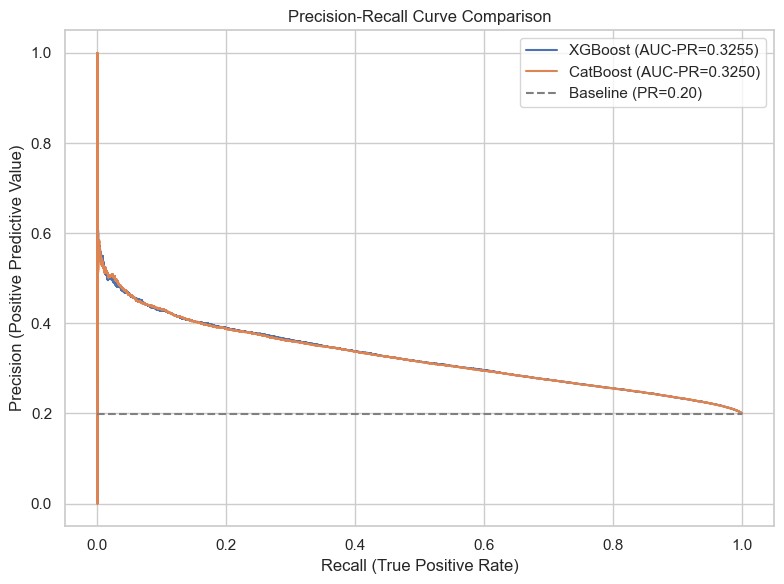


Project modeling complete. CatBoost is expected to perform best due to superior feature handling and engineering.
Final AUC-PR Score - XGBoost: 0.3255
Final AUC-PR Score - CatBoost: 0.3250


In [33]:
# PR Curve Plot 
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, xgb_proba)
auc_pr_xgb = auc(recall_xgb, precision_xgb)
precision_cat, recall_cat, _ = precision_recall_curve(y_test, cat_proba)
auc_pr_cat = auc(recall_cat, precision_cat)

plt.figure(figsize=(8, 6))
plt.title("Precision-Recall Curve Comparison")
plt.plot(recall_xgb, precision_xgb, label=f'XGBoost (AUC-PR={auc_pr_xgb:.4f})')
plt.plot(recall_cat, precision_cat, label=f'CatBoost (AUC-PR={auc_pr_cat:.4f})')

# Plot baseline (random classifier baseline is the ratio of positive class)
baseline_pr = y_test.sum() / len(y_test)
plt.plot([0, 1], [baseline_pr, baseline_pr], linestyle='--', color='gray', label=f'Baseline (PR={baseline_pr:.2f})')

plt.xlabel("Recall (True Positive Rate)")
plt.ylabel("Precision (Positive Predictive Value)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show() #

print("\nProject modeling complete. CatBoost is expected to perform best due to superior feature handling and engineering.")
print(f"Final AUC-PR Score - XGBoost: {auc_pr_xgb:.4f}")
print(f"Final AUC-PR Score - CatBoost: {auc_pr_cat:.4f}")